In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [8]:
from xgboost import XGBClassifier
from sklearn import metrics

In [9]:
df = pd.read_csv('bitcoin.csv')

In [11]:
df.head(15)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,402.152008,24127600
6,2014-09-23,402.092010,441.557007,396.196991,435.790985,435.790985,45099500
7,2014-09-24,435.751007,436.112000,421.131989,423.204987,423.204987,30627700
8,2014-09-25,423.156006,423.519989,409.467987,411.574005,411.574005,26814400
9,2014-09-26,411.428986,414.937988,400.009003,404.424988,404.424988,21460800


In [12]:
df.shape

(2713, 7)

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,2713.0,1.131104e+04,1.610643e+04,1.768970e+02,6.063970e+02,6.301570e+03,1.045240e+04,6.754973e+04
High,2713.0,1.161429e+04,1.653739e+04,2.117310e+02,6.092610e+02,6.434618e+03,1.076264e+04,6.878962e+04
Low,2713.0,1.097556e+04,1.560857e+04,1.715100e+02,6.041100e+02,6.214220e+03,1.020239e+04,6.638206e+04
Close,2713.0,1.132391e+04,1.611037e+04,1.781030e+02,6.067190e+02,6.317610e+03,1.046226e+04,6.756683e+04
Adj Close,2713.0,1.132391e+04,1.611037e+04,1.781030e+02,6.067190e+02,6.317610e+03,1.046226e+04,6.756683e+04
Volume,2713.0,1.470462e+10,2.001627e+10,5.914570e+06,7.991080e+07,5.098183e+09,2.456992e+10,3.509679e+11


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2713 entries, 0 to 2712
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2713 non-null   object 
 1   Open       2713 non-null   float64
 2   High       2713 non-null   float64
 3   Low        2713 non-null   float64
 4   Close      2713 non-null   float64
 5   Adj Close  2713 non-null   float64
 6   Volume     2713 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 148.5+ KB


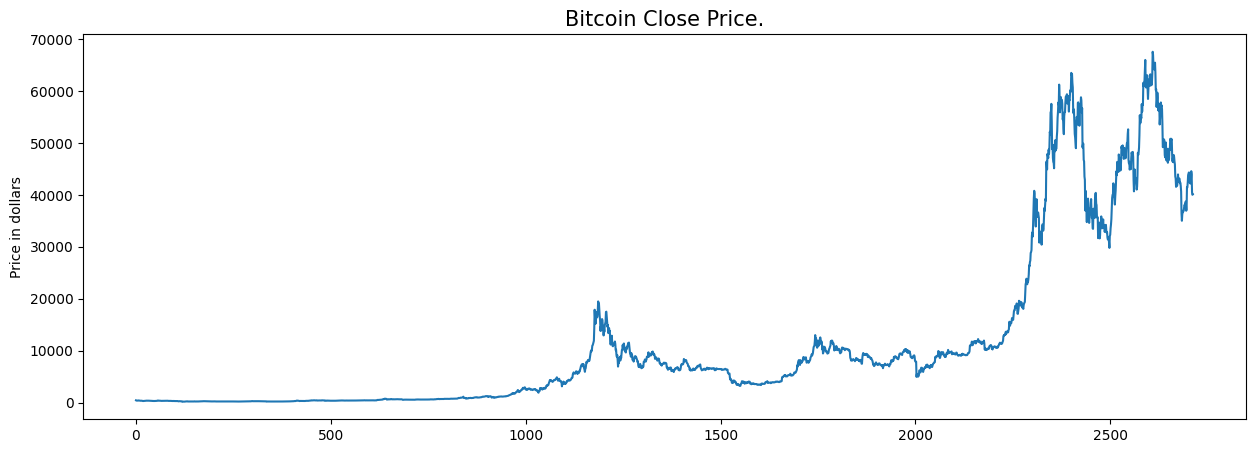

In [19]:
plt.figure(figsize=(15, 5))
plt.plot(df['Close'])
plt.title('Bitcoin Close Price.', fontsize=15)

plt.ylabel('Price in dollars')
plt.show()

In [21]:
df[df['Close'] == df['Adj Close']].shape, df.shape

((2713, 7), (2713, 7))

In [22]:
df = df.drop(['Adj Close'], axis=1)

In [23]:
df.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

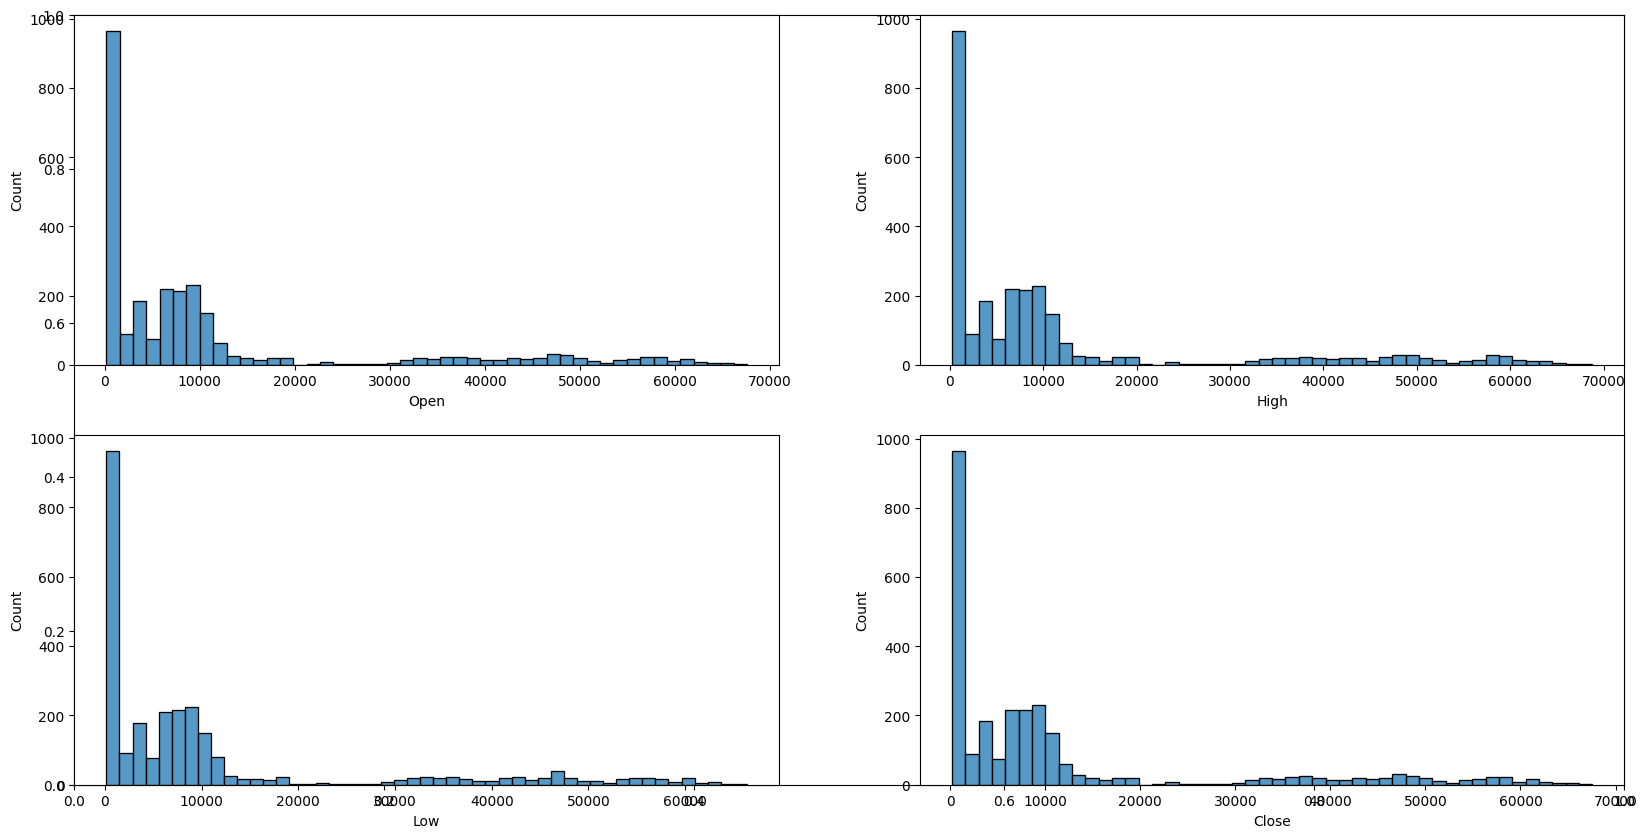

In [24]:
features = ['Open', 'High', 'Low', 'Close']

plt.subplots(figsize = (20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col])
plt.show()

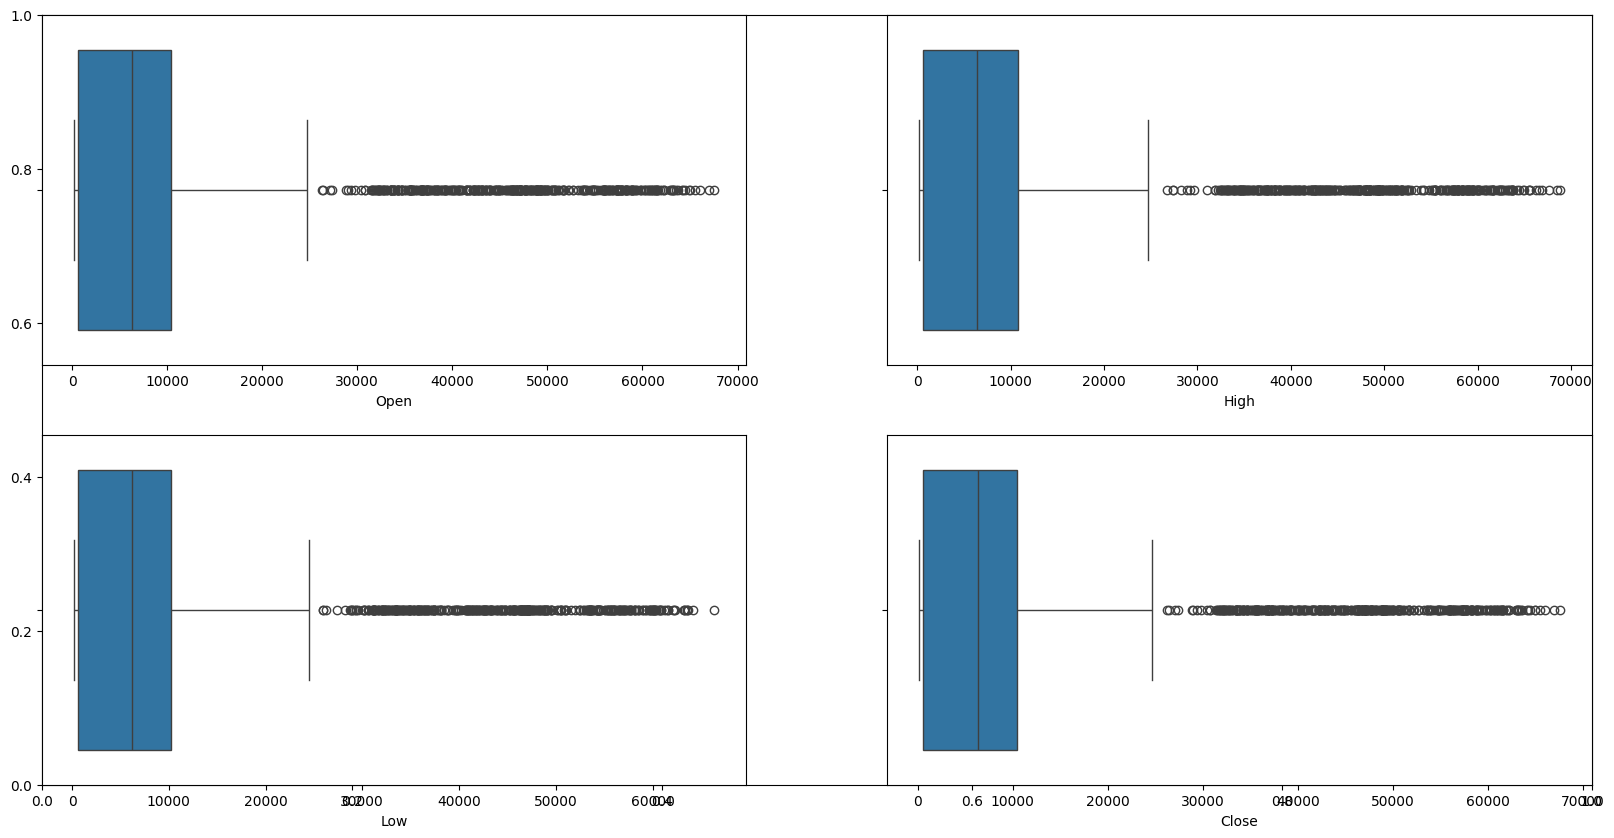

In [26]:
plt.subplots(figsize = (20, 10))
for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    sns.boxplot(df[col], orient='h')
plt.show()

In [28]:
splitted = df['Date'].str.split('-', expand=True)

df['year'] = splitted[0].astype('int')
df['month'] = splitted[1].astype('int') 
df['day'] = splitted[2].astype('int')

In [30]:
df['Date'] = pd.to_datetime(df['Date'])
df.head(15)

,Date,Open,High,Low,Close,Volume,year,month,day
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,24127600,2014,9,22
6,2014-09-23,402.092010,441.557007,396.196991,435.790985,45099500,2014,9,23
7,2014-09-24,435.751007,436.112000,421.131989,423.204987,30627700,2014,9,24
8,2014-09-25,423.156006,423.519989,409.467987,411.574005,26814400,2014,9,25
9,2014-09-26,411.428986,414.937988,400.009003,404.424988,21460800,2014,9,26


In [31]:
df.groupby('year').mean()

,Date,Open,High,Low,Close,Volume,month,day
year,,,,,,,,
2014,2014-11-08 12:00:00,365.058217,373.265397,355.903726,363.693085,2.383690e+07,10.735849,16.849057
2015,2015-07-02 00:00:00,272.149011,278.151978,266.807891,272.453381,3.390557e+07,6.526027,15.720548
2016,2016-07-01 12:00:00,567.141429,574.302273,560.453374,568.492407,8.592451e+07,6.513661,15.756831
2017,2017-07-02 00:00:00,3970.644848,4144.687445,3811.707792,4006.033629,2.382867e+09,6.526027,15.720548
2018,2018-07-02 00:00:00,7601.018680,7787.978969,7350.747939,7572.298947,6.063552e+09,6.526027,15.720548
2019,2019-07-02 00:00:00,7385.218456,7549.907409,7222.602868,7395.246282,1.673049e+10,6.526027,15.720548
2020,2020-07-01 12:00:00,11056.787201,11304.359035,10844.595163,11116.378092,3.302327e+10,6.513661,15.756831
2021,2021-07-02 00:00:00,47402.115663,48762.998925,45852.003082,47436.932021,4.715574e+10,6.526027,15.720548
2022,2022-01-25 12:00:00,41468.636797,42225.196172,40415.898360,41345.687735,2.718684e+10,1.380000,13.720000


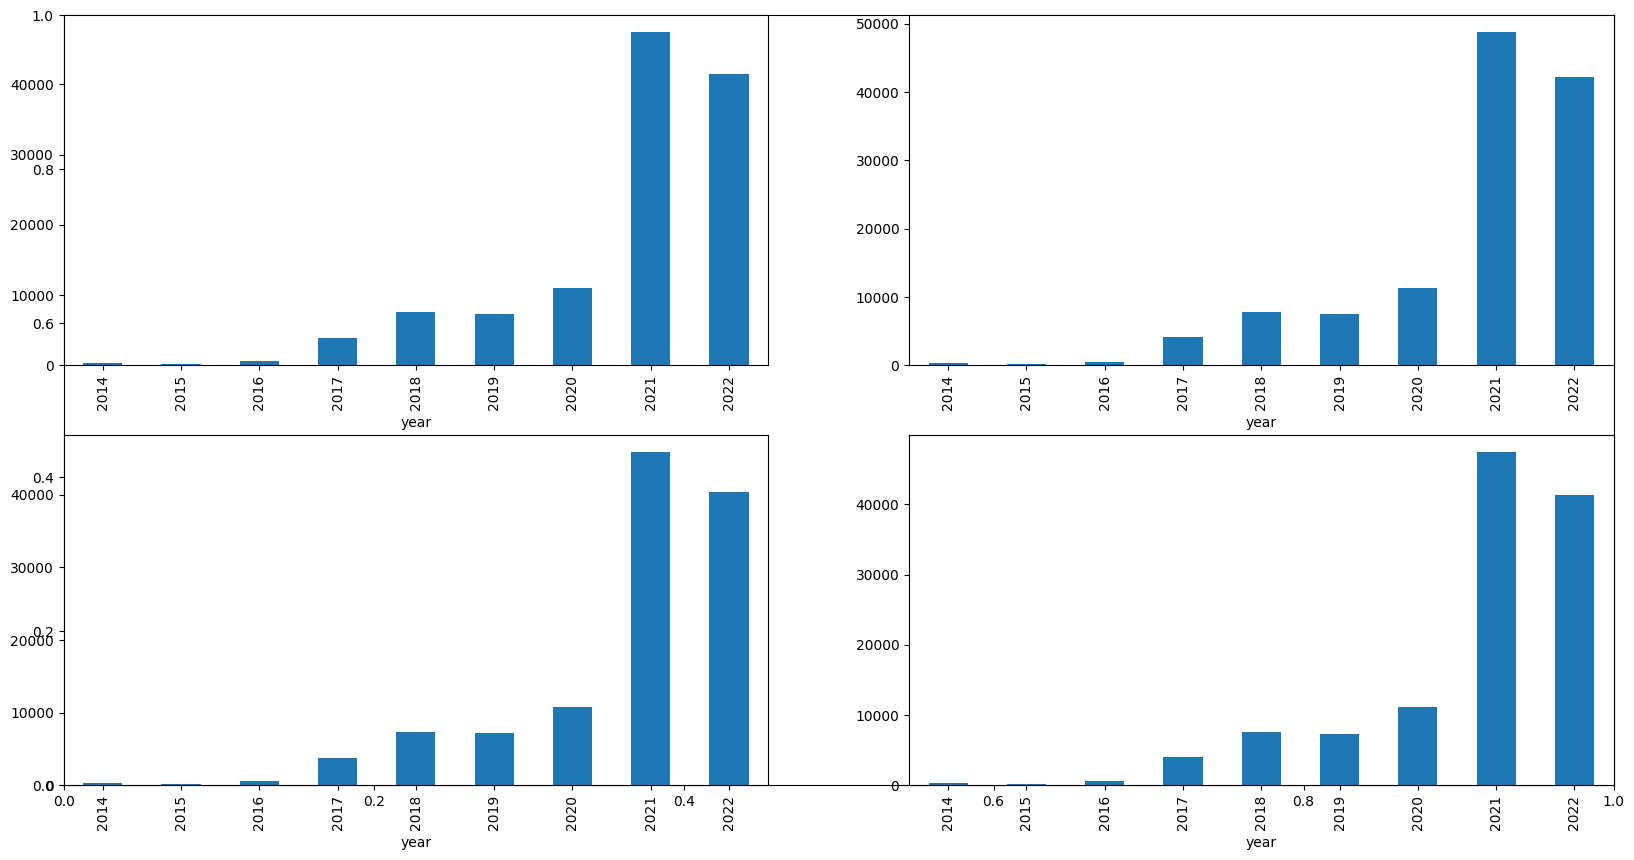

In [32]:
data_grouped = df.groupby('year').mean()
plt.subplots(figsize=(20,10))
for i, col in enumerate(['Open', 'High', 'Low', 'Close']):
  plt.subplot(2,2,i+1)
  data_grouped[col].plot.bar()
plt.show()

In [34]:
df['is_quarter_end'] = np.where(df['month']%3==0,1,0)
df.head(15)

,Date,Open,High,Low,Close,Volume,year,month,day,is_quarter_end
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,21056800,2014,9,17,1
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,34483200,2014,9,18,1
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,37919700,2014,9,19,1
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,36863600,2014,9,20,1
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,26580100,2014,9,21,1
5,2014-09-22,399.100006,406.915985,397.130005,402.152008,24127600,2014,9,22,1
6,2014-09-23,402.092010,441.557007,396.196991,435.790985,45099500,2014,9,23,1
7,2014-09-24,435.751007,436.112000,421.131989,423.204987,30627700,2014,9,24,1
8,2014-09-25,423.156006,423.519989,409.467987,411.574005,26814400,2014,9,25,1
9,2014-09-26,411.428986,414.937988,400.009003,404.424988,21460800,2014,9,26,1


In [35]:
df['open-close']  = df['Open'] - df['Close']
df['low-high']  = df['Low'] - df['High']
df['target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)

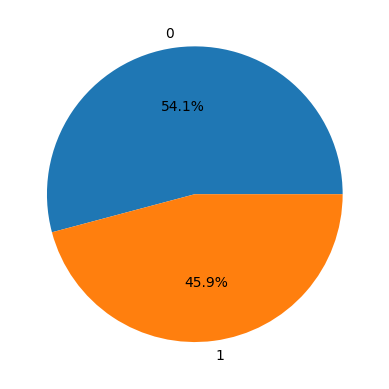

In [36]:
plt.pie(df['target'].value_counts().values, 
        labels=[0, 1], autopct='%1.1f%%')
plt.show()

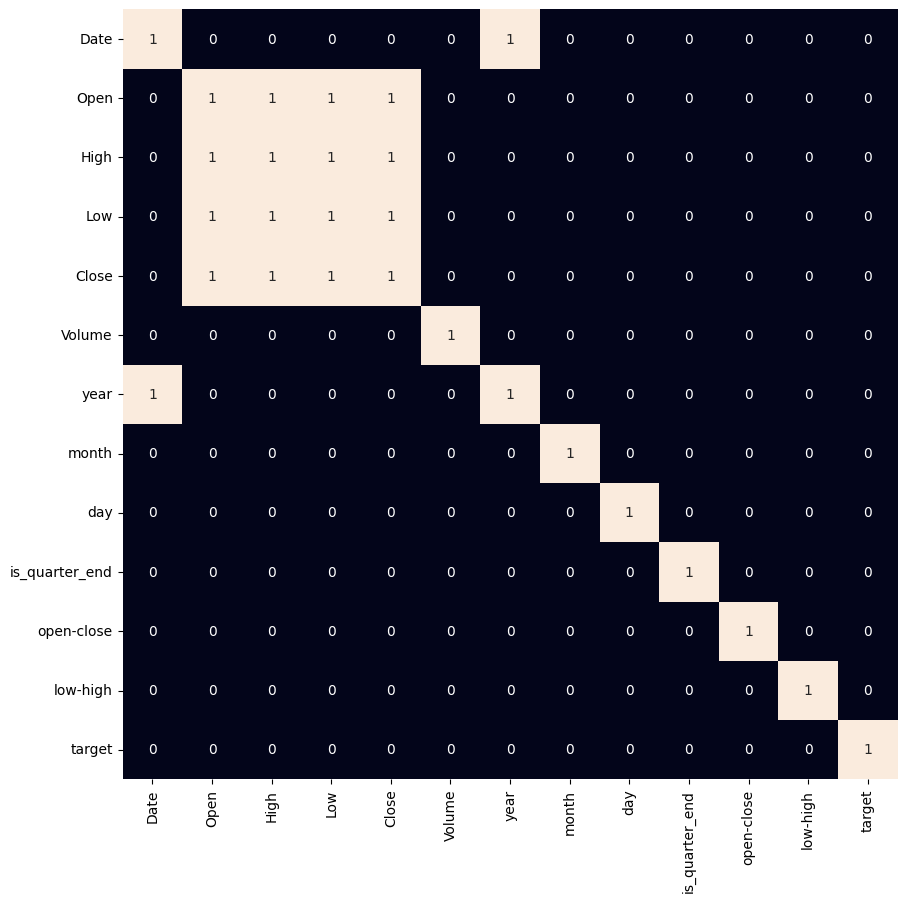

In [38]:
plt.figure(figsize=(10, 10))

sns.heatmap(df.corr() > 0.9, annot=True, cbar=False)
plt.show()

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Assuming df is already defined
features = df[['open-close', 'low-high', 'is_quarter_end']]
target = df['target']

# Scaling the features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Split the data into training and validation (test) sets
X_train, X_valid, Y_train, Y_valid = train_test_split(features, target, test_size=0.3, random_state=42)

# 'test_size=0.3' means 30% of the data will be used for testing, and 70% for training

In [40]:
models = [LogisticRegression(), SVC(kernel='poly', probability=True), XGBClassifier()]

for i in range(3):
  models[i].fit(X_train, Y_train)

  print(f'{models[i]} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(Y_train, models[i].predict_proba(X_train)[:,1]))
  print('Validation Accuracy : ', metrics.roc_auc_score(Y_valid, models[i].predict_proba(X_valid)[:,1]))
  print()

LogisticRegression() : 
Training Accuracy :  0.5319642853158836
Validation Accuracy :  0.5117827868852459

SVC(kernel='poly', probability=True) : 
Training Accuracy :  0.5341406767673837
Validation Accuracy :  0.5287556108508977

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Traini

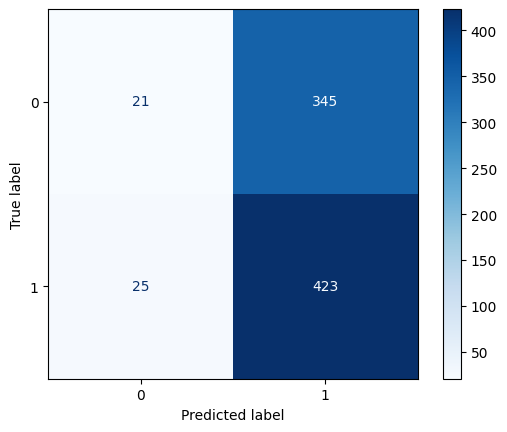

In [41]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(models[0], X_valid, Y_valid, cmap='Blues')
plt.show()